In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [84]:
# import database
conn = sqlite3.connect('customer_churn.db')

sql_query = """
SELECT Name FROM sqlite_master
WHERE type ='table'
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [85]:
# print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [8]:
#Data cleaning
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
#A. Rename column = Name
#B. Drop columns = Interests and Pincode
#C. Change datatype of DOB
#C. Data Standardization = Gender
#E. Fix missing values = Country

In [86]:
#A
df_db_customer.rename(columns = {'name':'customer_name'}, inplace = True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [121]:
# B
df_db_customer = df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [43]:
# C
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [87]:
# D
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [46]:
# E
df_db_customer[df_db_customer['country'].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [51]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [55]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [56]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [58]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [154]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
 11  churn_flag               21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(3), str(5

In [66]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [200]:
#df_db_support.drop(columns=['col_1','comment'], inplace = True)

In [189]:
df_db_support.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 2 to 3
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customerid       7 non-null      str  
 1   complaint_date   7 non-null      str  
 2   escalations      7 non-null      str  
 3   csat_score       7 non-null      int64
 4   complaint_count  7 non-null      int64
dtypes: int64(2), str(3)
memory usage: 336.0 bytes


In [69]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
#Feature Engineering

In [126]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1,0)

df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [190]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15 00:00:00,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20 00:00:00,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,NaN,Delhi,Female,1988-12-10 00:00:00,2025-03-18 00:00:00,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21 00:00:00,2024-11-01 00:00:00,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,NaN,Kathmandu,Female,1985-07-07 00:00:00,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,NaN,NaN,NaN


In [191]:
df.shape

(21, 21)

In [96]:
df_db_subscription['customerid'].nunique()

21

In [97]:
df_db_customer['customerid'].nunique()

21

In [112]:
df_db_support['customerid'].nunique()

7

In [111]:
df_db_support['customerid'].size

7

In [107]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [192]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,1
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,1


In [110]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [193]:
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [194]:
df.shape

(21, 21)

In [195]:
df.to_csv('exported_churn_analysis_data.csv', index=False)

In [ ]:
#Data Analysis

In [132]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [133]:
# 2. Retention Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [161]:
# 3. Churn by Plan Type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [160]:
# 4. Churn by State along with total revenue and user count
churn_by_state = (df.groupby('state').agg(churn_rate_by_state = ('churn_flag', lambda x: round(x.mean() * 100,2)),total_revenue = ('monthly_charges','sum'),user_count = ('customerid','count')).reset_index())
print(churn_by_state)

           state  churn_rate_by_state  total_revenue  user_count
0          Delhi                25.00          52.96           4
1      Karnataka               100.00          20.98           2
2      Kathmandu                 0.00          20.98           2
3    Maharashtra                 0.00          50.97           3
4      Meghalaya                66.67          42.97           3
5       Nagaland                 0.00          22.99           1
6      Rajasthan                 0.00          36.98           2
7      Telangana                50.00          30.98           2
8  Uttar Pradesh                 0.00         115.98           2


In [159]:
# 5. Churn by subscription_type along with total revenue and user count
churn_by_subtype = (df.groupby('subscription_type').agg(churn_rate_by_state = ('churn_flag', lambda x: round(x.mean() * 100,2)),total_revenue = ('monthly_charges','sum'),user_count = ('customerid','count')).reset_index())
print(churn_by_subtype)

  subscription_type  churn_rate_by_state  total_revenue  user_count
0           Organic                 0.00         145.91           9
1              Paid                16.67         174.94           6
2          Refferal                83.33          74.94           6


In [148]:
# 6. ARPU - Average Revenue Per User
arpu = df['monthly_charges'].mean()
print("ARPU = ", round(arpu,2))

ARPU =  18.85


In [207]:
# 7. Average Tenure of Customers
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(), 
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
(today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Average tenure (Days) = ", round(avg_tenure),0)

Average tenure (Days) =  1508 0


In [166]:
# 8. Revenue at risk 
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk (In K) = ", revenue_at_risk)

Revenue at risk (In K) =  73.94


In [196]:
# 9. Escalation rate
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation rate = ", round(escalation_rate,2),"%")

Escalation rate =  19.05 %


In [169]:
# 10. Average Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [198]:
# 11. Correlation Escalation vs Churn
#df['escalations']=np.where(df['escalations']== 'Y',1, 0)
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalations vs churn is = ", round(correlation,2))

Correlation between escalations vs churn is =  0.77


In [201]:
# 12. Churn risk
conditions = [(df['churn_score'] < 50),
              (df['churn_score'] >= 50) & (df['churn_score'] < 70),
              (df['churn_score'] >= 70)]

choices = ['Low','Medium','High']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [203]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,Low,12
1,High,91
2,Low,34
3,Low,8
4,High,88


In [ ]:
#Visualization Using Matplotlib

In [208]:
df_visual = df.copy()

In [210]:
df_visual.shape

(21, 23)

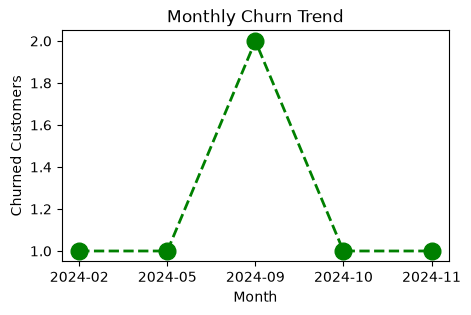

In [230]:
# 1. Monthly Churn Trend (Time Series KPI)
#df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize=(5,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

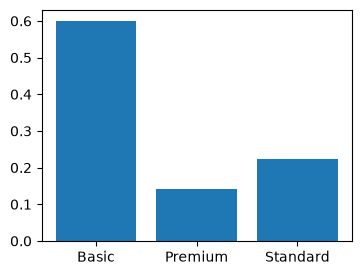

In [227]:
# 2. Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(4,3))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

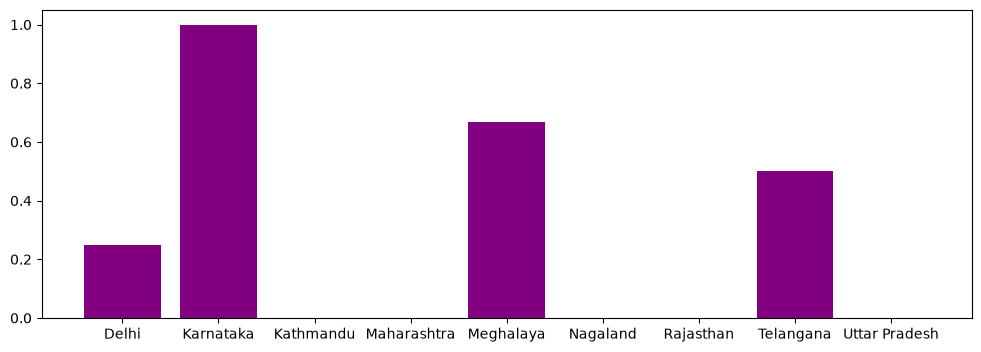

In [239]:
# 3. Churn By States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color='purple')
plt.show()

In [ ]:
#Visualization Using Seaborn

In [246]:
# 1. Correlation Matrix
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
order_mappings = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['Low','Medium','High']
}
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

<Axes: >

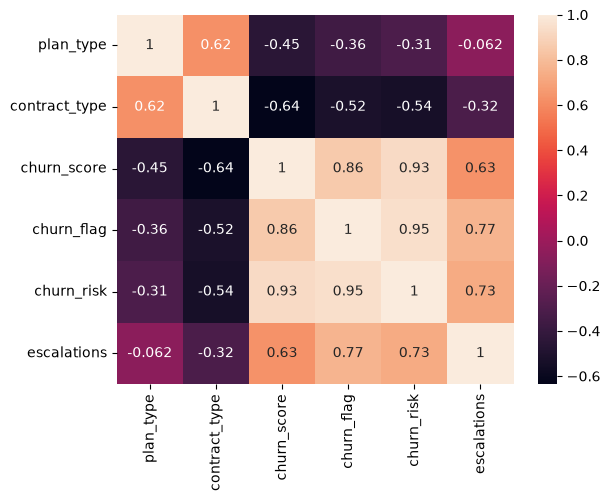

In [247]:
sns.heatmap(df_encoded.corr(), annot=True)

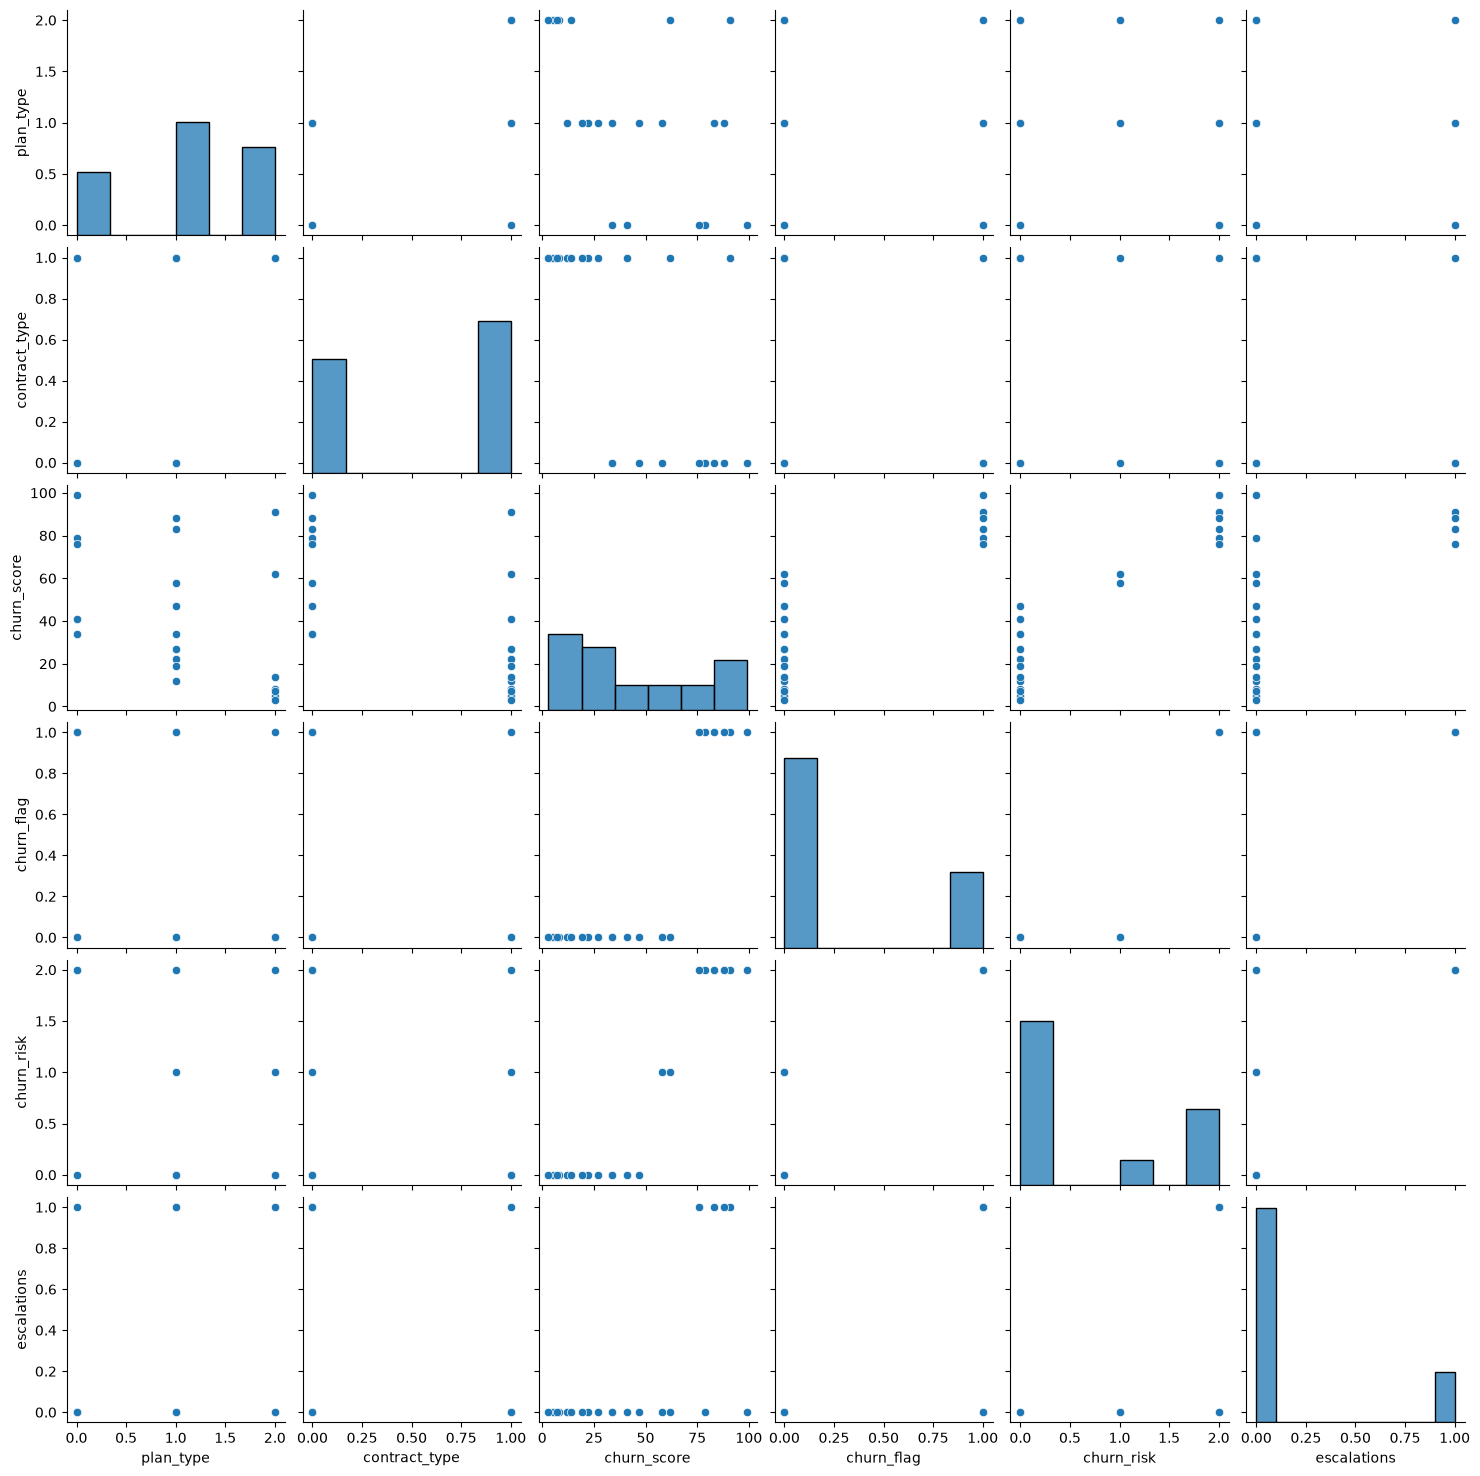

In [249]:
# 2. Pairplot
sns.pairplot(df_encoded)

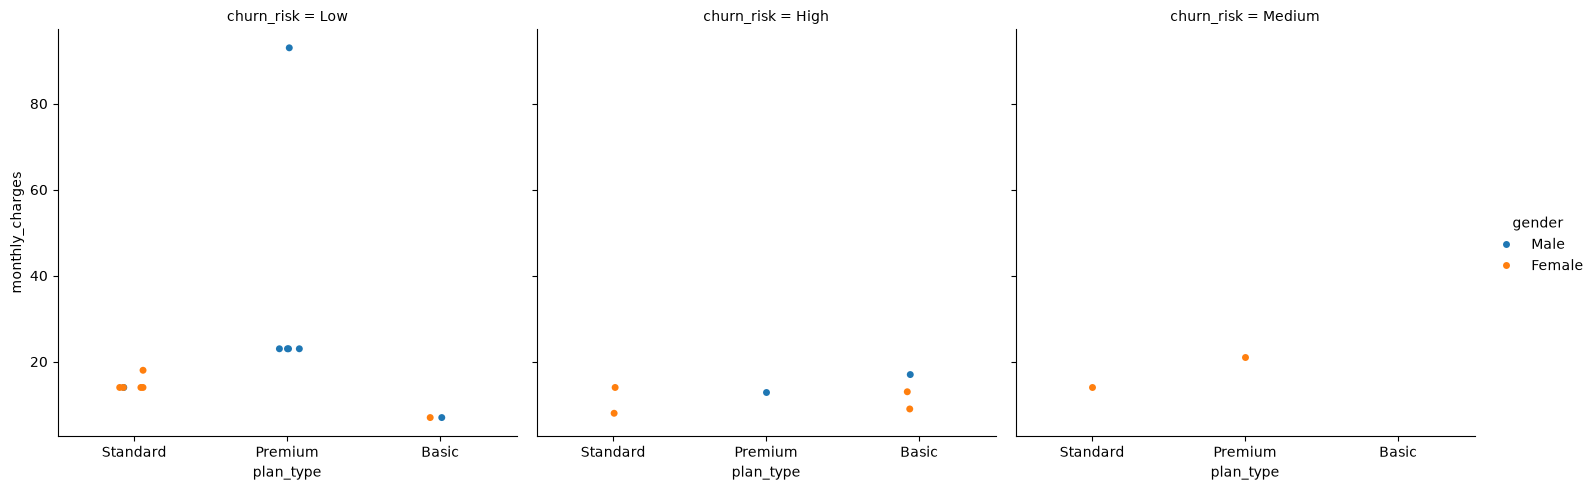

In [250]:
# 3. Facegrid Plot
sns.catplot(data = df_visual, 
            x = 'plan_type', 
            y = 'monthly_charges', 
            hue = 'gender', 
            col ='churn_risk')

In [ ]:
# Pivot Tables

In [252]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [253]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [254]:
conn.close()